<a href="https://colab.research.google.com/github/suzetteabascal10-byte/Simulacion-I/blob/main/Flecha_y_cojinte.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import numpy as np
import math as m
import matplotlib.pyplot as plt
import random as a
from scipy import stats
import seaborn as sns

utilizando una aproximacion de la nomal decidimos usar el metodo de las 12 uniformes y asi calcular las probabilidades solicitadas y el n aproximado para el valor de verdadero de 0.01

In [15]:
def normal_12_uniformes(mu, sigma, rng):
    U = rng.uniform(0, 1, 12)
    Z = U.sum() - 6
    return mu + sigma * Z

mu1, sigma1 = 1.5, 0.04   # varianza 0.0016
mu2, sigma2 = 1.48, 0.03  # varianza 0.0009

n_sim = 100000
rng = np.random.default_rng(123)

U_all = rng.uniform(0, 1, (n_sim, 24))

Z1 = U_all[:, :12].sum(axis=1) - 6
Z2 = U_all[:, 12:].sum(axis=1) - 6

X1 = mu1 + sigma1 * Z1
X2 = mu2 + sigma2 * Z2

interferencias = np.sum(X1 > X2)
p_estimado = interferencias / n_sim

print("a) Probabilidad de interferencia estimada ")

sigma_d = np.sqrt(sigma1**2 + sigma2**2)
mu_d = mu1 - mu2
z = -mu_d / sigma_d
p_teorico = stats.norm.cdf(mu_d / sigma_d)
print("   Valor teórico:", p_teorico)


print("b) Probabilidad de interferencia estimada ")
E = 0.01
confianza = 0.95
z = stats.norm.ppf(1 - (1 - confianza)/2)

p_peor = 0.5
n_peor_caso = np.ceil((z / E)**2 * p_peor * (1 - p_peor))

n_real = np.ceil((z / E)**2 * p_teorico * (1 - p_teorico))

print(" Tamaño de muestra necesario (con p=0.5 como peor caso)", n_peor_caso)
print("Tamaño de muestra necesario (con p teórica )", p_teorico)

a) Probabilidad de interferencia estimada 
   Valor teórico: 0.6554217416103243
b) Probabilidad de interferencia estimada 
 Tamaño de muestra necesario (con p=0.5 como peor caso) 9604.0
Tamaño de muestra necesario (con p teórica ) 0.6554217416103243


:## Histograma

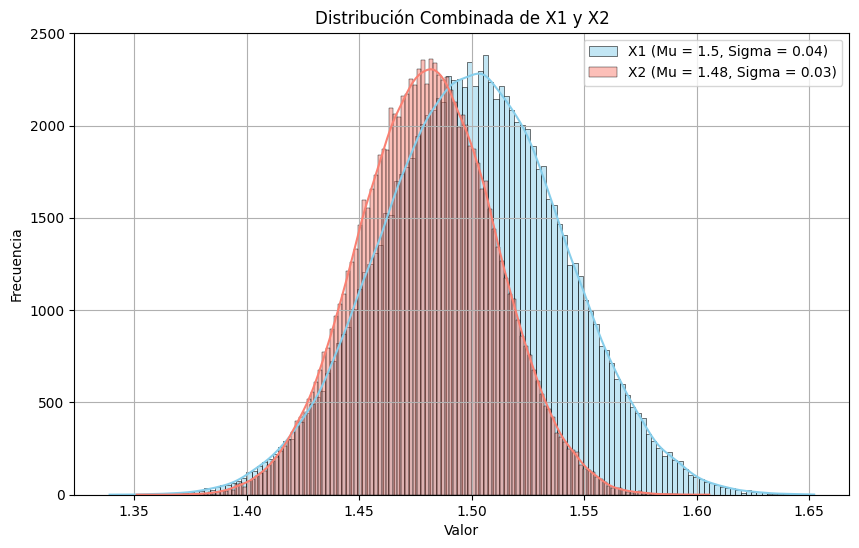

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(X1, kde=True, color='skyblue', label='X1 (Mu = 1.5, Sigma = 0.04)', alpha=0.5)
sns.histplot(X2, kde=True, color='salmon', label='X2 (Mu = 1.48, Sigma = 0.03)', alpha=0.5)
plt.title('Distribución Combinada de X1 y X2')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True)
plt.show()